# Fetch Reach Environment Demo

This notebook demonstrates the MuJoCo Fetch Reach robotic environment.

In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [3]:
env = gym.make("fetch_reach/easy")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names() if hasattr(env.action_space, 'get_function_names') else 'Discrete actions'}")
print(f"Observation Space: {env.observation_space}")

Action Space: FuncConditional(['move', 'stop'])
Available actions: ['move', 'stop']
Observation Space: Dict('achieved_goal': Box(-inf, inf, (3,), float64), 'desired_goal': Box(-inf, inf, (3,), float64), 'image': Box(0, 255, (480, 960, 3), uint8), 'observation': Box(-inf, inf, (10,), float64))


## 2. Reset and View Initial State

Observation type: <class 'dict'>
Info: {}


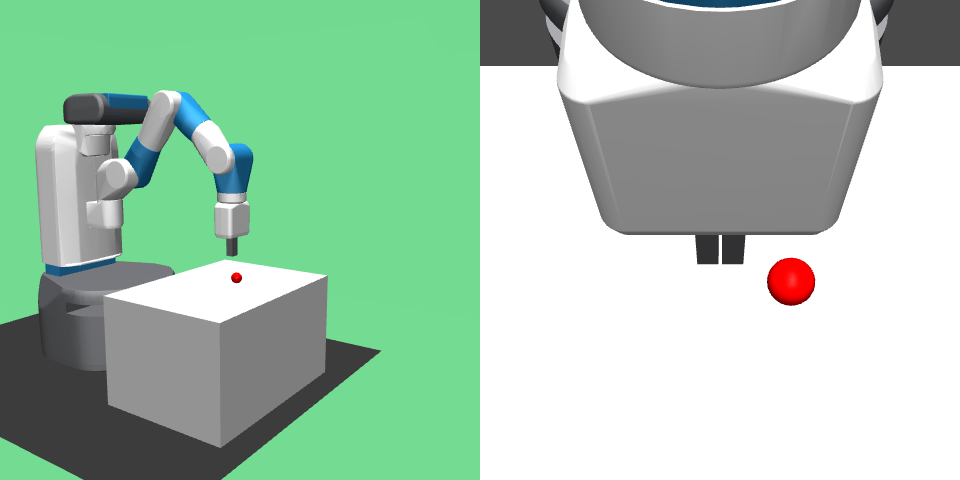


Task: Move the robot end-effector to reach the target

Task Prompt:
You are controlling a robotic arm to reach a target 3D position. The left image is a front view of the robot, and the right image moving camera attached to the gripper. Your goal is to move it to the red target marker. Each action moves the end-effector by a fixed step size in the specified direction.

Available actions:
1. 'move': Move the end-effector in 3D space. Format: `('move', [x, y, z])` where each element is -1, 0, or 1:
   - x: -1=left, 0=no change, 1=right
   - y: -1=backward, 0=no change, 1=forward
   - z: -1=down, 0=no change, 1=up
2. 'stop': End the reaching session. Format: `('stop', 'stop')`

Success: You succeed when the end-effector reaches the target position (red marker).

Please respond with exactly one action and its arguments in the specified format. For example:
- To move right and up: `('move', [1, 0, 1])`
- To move forward: `('move', [0, 1, 0])`
- To move down and left: `('move', [-1, 0, -1])

In [4]:
obs, info = env.reset()
print(f"Observation type: {type(obs)}")
print(f"Info: {info}")

frame = env.render()
display(Image.fromarray(frame))
print(f"\nTask: Move the robot end-effector to reach the target")
print(f"\nTask Prompt:\n{env.get_prompt() if hasattr(env, 'get_prompt') else 'Standard Fetch Reach task'}")

## 3. Test Random Actions

Step 1: Reward = 0.0000, Done = False


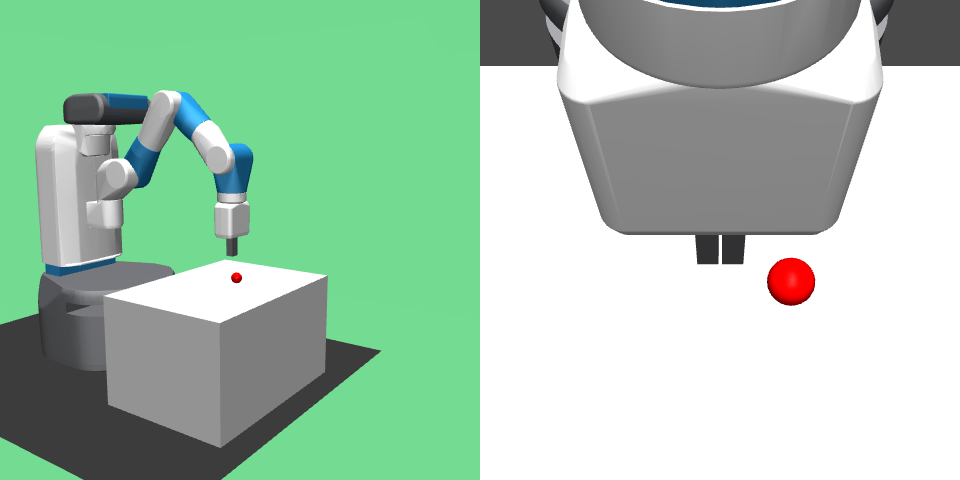

Step 2: Reward = 0.0000, Done = False
Step 3: Reward = 0.0000, Done = False
Step 4: Reward = 0.0000, Done = False
Step 5: Reward = 0.0000, Done = False


/home/junyi42/VLM-Gym/current/gymnasium/spaces/box.py:423: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [5]:
# Test a few random actions
for i in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Step {i+1}: Reward = {reward:.4f}, Done = {terminated or truncated}")
    if i == 0 or terminated:
        frame = env.render()
        display(Image.fromarray(frame))
    if terminated:
        break

## 4. Test Solver

Initial configuration:


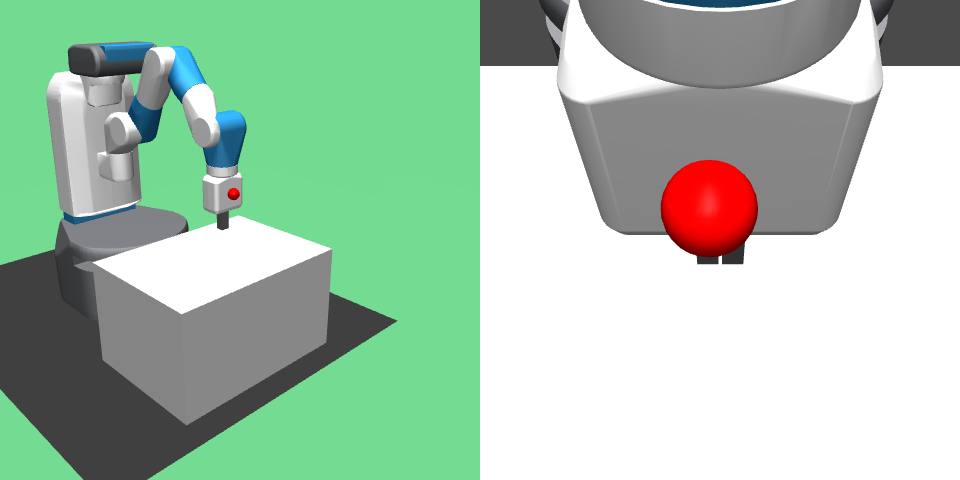


Solver generated 11 actions
Step 1: action = ('move', [0, 0, 1]), Reward = 0.0000, Done = False


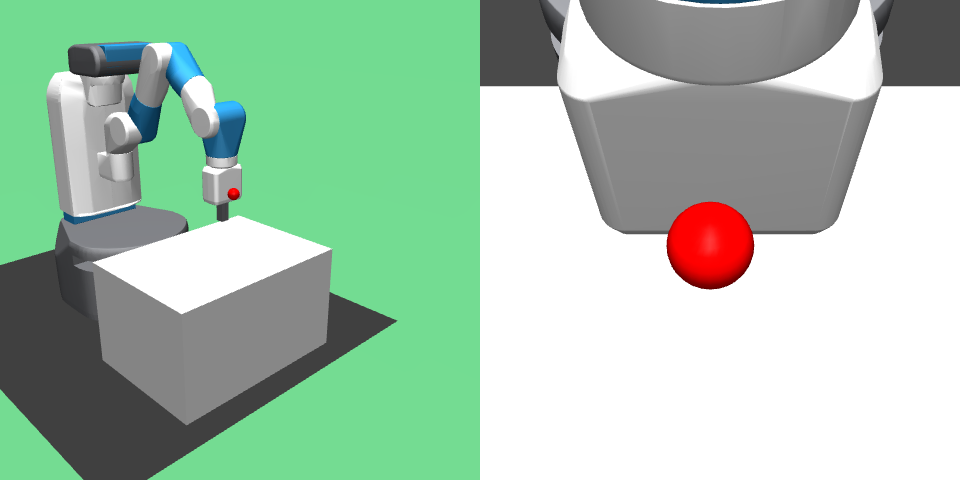

Step 3: action = ('move', [1, 0, 0]), Reward = 0.0000, Done = False


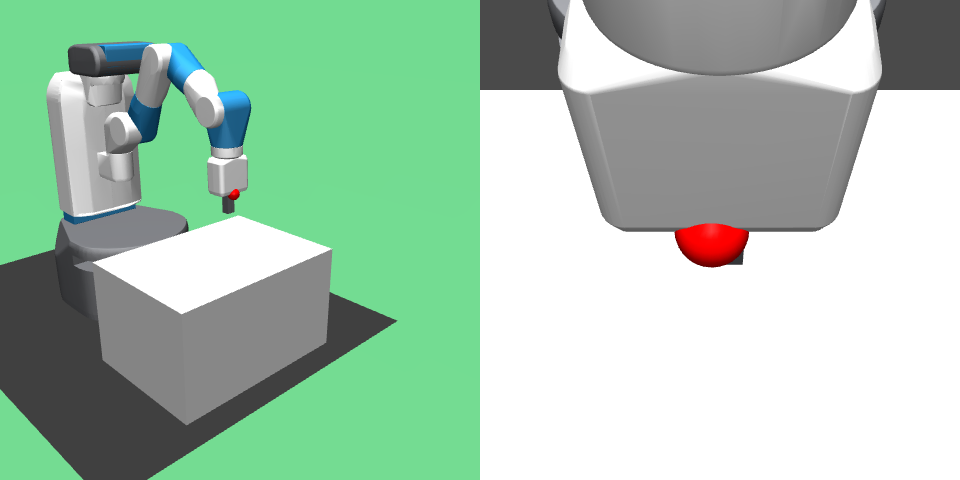

Step 5: action = ('move', [1, 0, 0]), Reward = 0.0000, Done = False


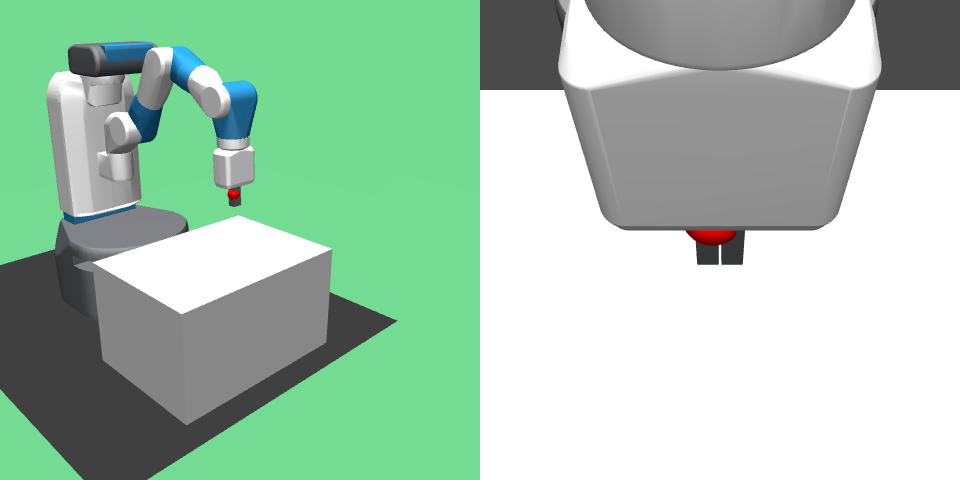

Step 7: action = ('move', [0, 0, -1]), Reward = 0.0000, Done = False


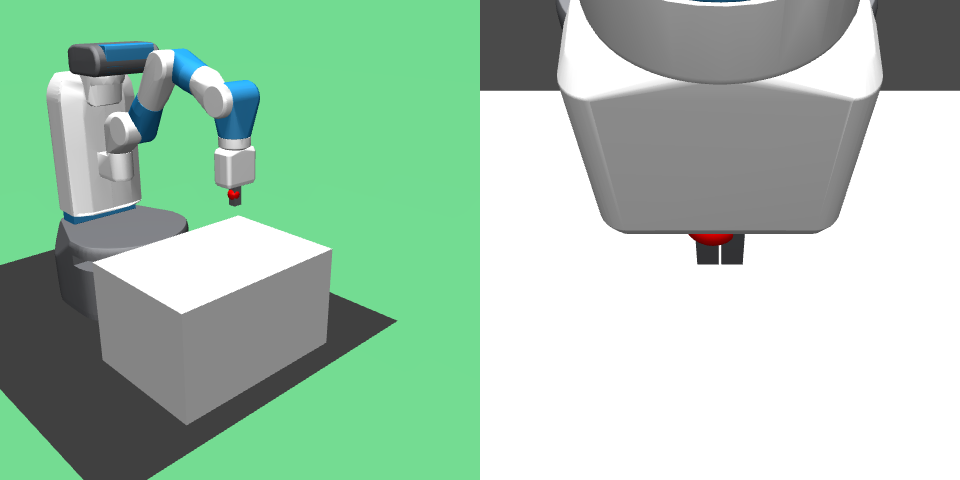

Step 9: action = ('move', [0, 0, -1]), Reward = 0.0000, Done = False


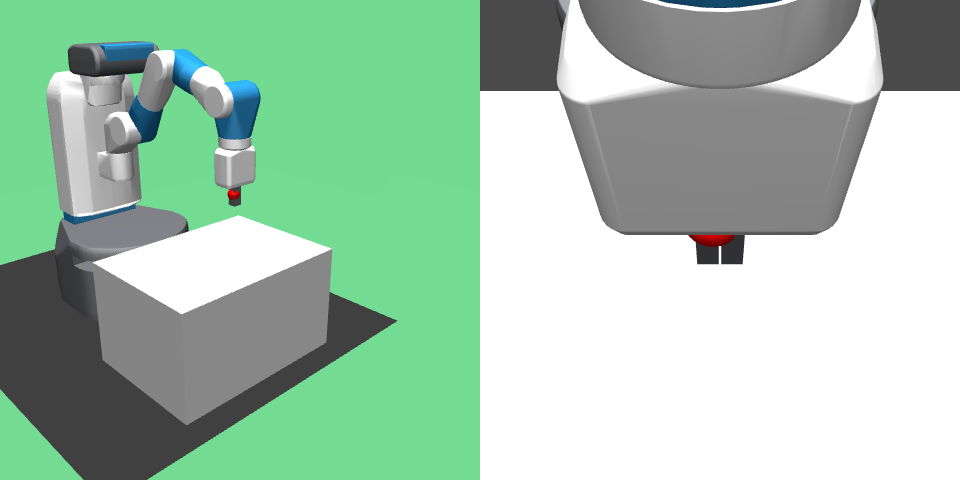

Step 11: action = ('stop', 'stop'), Reward = 1.0000, Done = True


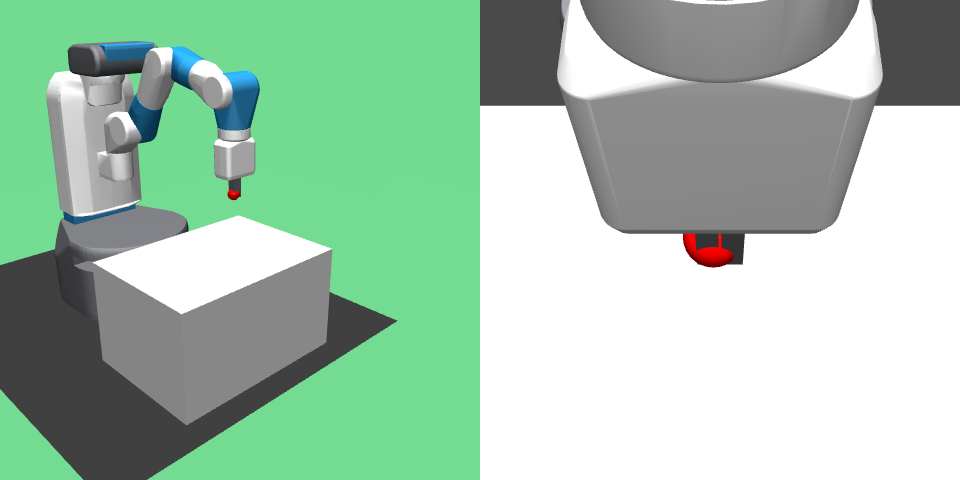

In [11]:
env = gym.make("fetch_reach/easy")
obs, info = env.reset()
print("Initial configuration:")
frame = env.render()
display(Image.fromarray(frame))

# Get solver actions if available
if hasattr(env, 'solve'):
    actions = env.solve()
    print(f"\nSolver generated {len(actions)} actions")
    
    # Execute solver actions
    for i, action in enumerate(actions):
        obs, reward, terminated, truncated, info = env.step(action)
        if i % 2 == 0 or terminated:  # Show every 2nd step
            print(f"Step {i+1}: action = {action}, Reward = {reward:.4f}, Done = {terminated or truncated}")
            frame = env.render()
            display(Image.fromarray(frame))
        if terminated:
            break
else:
    print("Solver not available for this environment")

env.close()